In [1]:
import numpy as np
import matplotlib.pyplot as plt
from define_data_and_variables import get_data, get_hmc_config
import arviz as az
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import os
import gc
from pathlib import Path
from define_data_and_variables import hmc_config, data, hash_configs
import json

# TODO: fix so that it is easy to run either with fixed dF or updating dF. Need to increase maximum temp. Maybe increase number of shared chains for this as well.:)


In [2]:
base_dir = Path.cwd()
np.random.seed(hmc_config["sd"])
sp = np.random.multivariate_normal(data["pm"]* np.ones(data["N"]), data["ps"]**2 * np.eye(data["N"]), (hmc_config["nch"]))
sp = np.exp(sp)
print(sp)
hmc_config["sp"] = np.ascontiguousarray(sp)
hmc_hash = hash_configs(hmc_config, data)
output_dir = base_dir / f"output/{hmc_hash}"

[[ 7.90689172  5.03521165  8.80246894 16.39763831  4.70350134  4.70355622
  17.06563083  9.58439123  3.97913538  8.16876245  3.99630045  3.9897392
   6.59744588  1.42611181  1.63039268  3.72513187  2.70445638  6.94523338
   2.91359376  2.03601763 15.74238223  4.73158756  5.82822384  2.01808989
   3.77283685  6.01076894  2.45152153  7.25527348  3.62497026  4.51503641
   3.62222005 20.72071875  5.50208726  2.61955601  9.96722957  2.33279336
   6.44406374  1.37986055  2.16144758  6.38932916  9.38908832  6.27461066
   5.11679755  4.48494218  1.94241962  3.33051425  4.00420086 11.77544895
   7.09173143  1.58681262]
 [ 6.99395691  4.22509617  3.43367644  8.58003797 11.55884981 10.76802162
   3.05961199  4.45917051  7.02973438 11.11215908  3.95179881  4.86843322
   2.530578    2.37399918  9.89650933 14.56468537  5.2779745  11.33540293
   7.18312642  3.51216758  7.18189917 16.57345945  5.41546329 16.88983981
   0.8631793   9.96267998  5.90963666  4.49162915  5.92946734  1.35277058
   4.7521597

In [3]:
colors = plt.cm.viridis(np.linspace(0, 1, hmc_config["nch"]))

In [4]:
def expected_ages(N, delta_c, cs, theta, num_depths, depths, sed_rates, indices):
    cumulative_sum_vec = [0.0] * (N + 1)
    
    # Build cumulative sum vector
    for i in range(1, N + 1):
        cumulative_sum_vec[i] = cumulative_sum_vec[i - 1] + sed_rates[i - 1] * delta_c
    
    ages_out = [0.0] * num_depths
    
    # Compute ages
    for i in range(num_depths):
        index = indices[i]
        cumulative_sum = cumulative_sum_vec[index]
        cumulative_sum += sed_rates[index] * (depths[i] - cs[index])
        ages_out[i] = theta - cumulative_sum
    
    return ages_out


def get_index(N, cs, c14_depths, depth_index):
    low, high = 0, N - 1
    target = c14_depths[depth_index]
    
    while low <= high:
        mid = (low + high) // 2
        if cs[mid] < target:
            low = mid + 1
        else:
            high = mid - 1
    
    return low - 1 if low > 0 else 0

[[ 7.90689172  5.03521165  8.80246894 16.39763831  4.70350134  4.70355622
  17.06563083  9.58439123  3.97913538  8.16876245  3.99630045  3.9897392
   6.59744588  1.42611181  1.63039268  3.72513187  2.70445638  6.94523338
   2.91359376  2.03601763 15.74238223  4.73158756  5.82822384  2.01808989
   3.77283685  6.01076894  2.45152153  7.25527348  3.62497026  4.51503641
   3.62222005 20.72071875  5.50208726  2.61955601  9.96722957  2.33279336
   6.44406374  1.37986055  2.16144758  6.38932916  9.38908832  6.27461066
   5.11679755  4.48494218  1.94241962  3.33051425  4.00420086 11.77544895
   7.09173143  1.58681262]
 [ 6.99395691  4.22509617  3.43367644  8.58003797 11.55884981 10.76802162
   3.05961199  4.45917051  7.02973438 11.11215908  3.95179881  4.86843322
   2.530578    2.37399918  9.89650933 14.56468537  5.2779745  11.33540293
   7.18312642  3.51216758  7.18189917 16.57345945  5.41546329 16.88983981
   0.8631793   9.96267998  5.90963666  4.49162915  5.92946734  1.35277058
   4.7521597

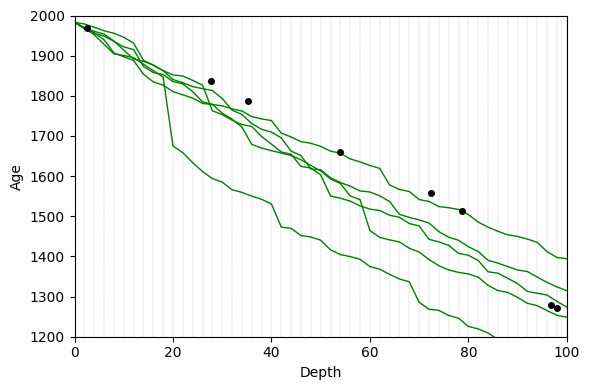

In [5]:
print(sp)
cumulative_sums = np.cumsum(sp, axis=1) * data["dc"]
zeros = np.zeros((*sp.shape[:1], 1))
age_offsets = np.concatenate((zeros, cumulative_sums), axis=1)
print(np.shape(age_offsets))

model_ages = data["th"] - age_offsets

# Age depth trace plot
fig, ax = plt.subplots(figsize=(6, 4))
num_samples = len(sp)
for j in range(num_samples):
    ax.plot(
        data["cs"],
        model_ages[j, :],
        color='green',
        alpha=1,
        linewidth=1,
    )
for i, c in enumerate(data["cs"]):
    ax.axvline(x=c, color='k', linestyle='--', linewidth = 0.1)

ax.set_xlim(0, np.max(data["cs"]))
ax.set_ylim(1200, 2000)
plt.plot(data["c14d"], np.squeeze(data["c14"]), "ko", markersize=4)
# plt.plot(config["cs"], data["theta"] - config["dc"] * np.cumsum((config["a"]/config["b"]) * np.ones_like(config["cs"])), color = 'k', linewidth=0.5)
plt.xlabel("Depth")
plt.ylabel("Age")
plt.tight_layout()
plt.savefig(f"{output_dir}/sp_age_depth.jpg")
plt.show()

In [6]:
samples = np.load(f"{output_dir}/samples.npy")

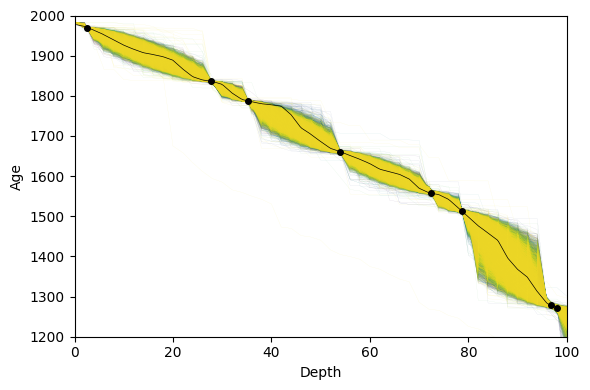

In [7]:
cumulative_sums = np.cumsum(samples, axis=2) * data["dc"]
zeros = np.zeros((*samples.shape[:2], 1))
age_offsets = np.concatenate((zeros, cumulative_sums), axis=2)

model_ages = data["th"] - age_offsets

# Age depth trace plot
fig, ax = plt.subplots(figsize=(6, 4))
num_samples = len(samples[0,:,0])
for i in range(hmc_config["nch"]):
    for j in range(num_samples):
        ax.plot(
            data["cs"],
            model_ages[i, j, :],
            color=colors[i],
            alpha=0.3,
            linewidth=0.1,
        )

ax.set_xlim(0, np.max(data["cs"]))
ax.set_ylim(1200, 2000)
plt.plot(data["c14d"], np.squeeze(data["c14"]), "ko", markersize=4)
plt.plot(data["d18od"], data["d18ota"], color = 'k', linewidth=0.5)
plt.xlabel("Depth")
plt.ylabel("Age")
plt.tight_layout()
plt.savefig(f"{output_dir}/age_depth_samples.jpg")
plt.show()

In [8]:
# Print R_hat and N_eff using arviz
idata = az.convert_to_inference_data(samples)
summary = az.summary(idata, round_to=2)
print(summary)

        mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd   ess_bulk  ess_tail  \
x[0]    5.02   0.91    3.29     6.49       0.00     0.01  193353.57  19549.49   
x[1]    5.85   3.52    0.82    12.49       0.01     0.04  209580.44  16969.34   
x[2]    5.26   3.26    0.73    11.31       0.01     0.03  115760.49  23184.78   
x[3]    5.24   3.24    0.72    11.19       0.01     0.03  105496.05  21131.16   
x[4]    5.28   3.28    0.71    11.39       0.01     0.03  114841.17  22745.59   
x[5]    5.26   3.27    0.75    11.35       0.01     0.03  115321.64  21601.25   
x[6]    5.26   3.29    0.66    11.23       0.01     0.04  121193.23  20755.69   
x[7]    5.28   3.32    0.63    11.40       0.01     0.03  133714.45  19487.77   
x[8]    5.25   3.25    0.76    11.27       0.01     0.03  102584.76  20928.39   
x[9]    5.26   3.28    0.74    11.31       0.01     0.04  124136.22  20080.32   
x[10]   5.24   3.24    0.79    11.23       0.01     0.03  124647.88  24033.88   
x[11]   5.26   3.29    0.66 

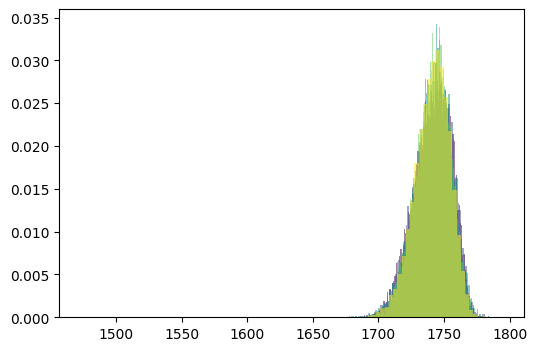

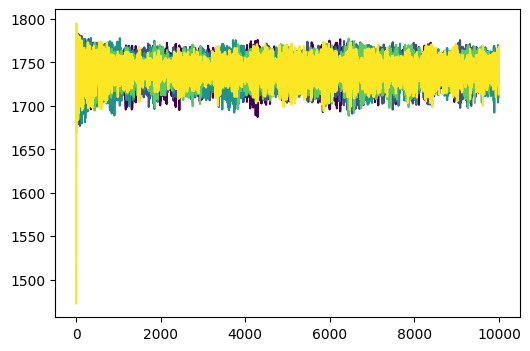

In [9]:
index = 21
interesting_depth = index * data["dc"]
CV_values = data["th"] - data["dc"] * np.sum(samples[:, :, :index], axis = 2)
fig, ax = plt.subplots(figsize=(6, 4))
for i in range(hmc_config["nch"]):
    ax.hist(CV_values[i, :], bins = 100, color = colors[i], label = f"chain {i}", alpha = 0.5, density = True)
plt.savefig(f"{output_dir}/samples_along_depth_{interesting_depth}.jpg")
plt.show()

fig, ax = plt.subplots(figsize=(6, 4))
for i in range(hmc_config["nch"]):
    ax.plot(CV_values[i, :], color = colors[i], label = f"chain {i}")
plt.savefig(f"{output_dir}/sampling_along_depth_evolution_{interesting_depth}.jpg")
plt.show()

In [10]:
energy_values = np.load(f"{output_dir}/energy.npy")

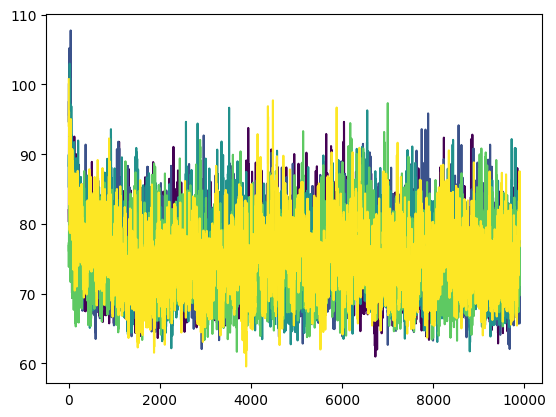

In [11]:
plt.figure()
for i in range(hmc_config["nch"]):
    plt.plot(energy_values[i,100:], color = colors[i])
plt.savefig(f"{output_dir}/energy.jpg")
plt.show()

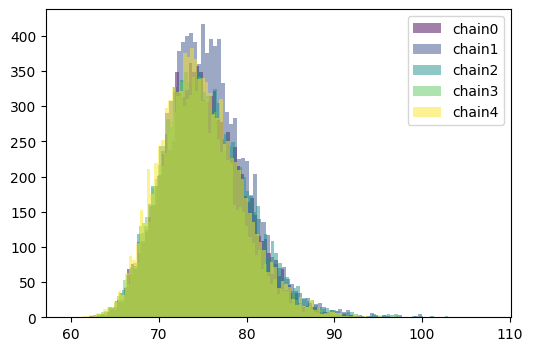

In [12]:
fig, ax = plt.subplots(figsize=(6, 4))
for i in range(hmc_config["nch"]):
    ax.hist(energy_values[i, 100:], color = colors[i], alpha = 0.5, label = f"chain{i}", bins = 100)
plt.legend()
plt.savefig(f"{output_dir}/energy_hist.jpg")
plt.show()   